In [23]:
import os
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset, Subset
import torch
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from typing import Tuple
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
import torch.nn.functional as F

In [24]:
# Проверяем наличие CUDA
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Используется GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("CUDA не найдена, используется CPU")

Используется GPU: NVIDIA GeForce RTX 3060


In [42]:

class FaceDataset(Dataset):
    def __init__(self, root_dir, transform=None, pairs_count=10000, pos_ratio=0.5, is_train=True):
        super().__init__()
        self.root_dir = root_dir
        self.transform = transform
        self.pairs_count = pairs_count
        self.pos_ratio = pos_ratio
        self.is_train = is_train


        self.identity_images = {}
        self.identities = []

        if is_train :
            images = []
            for identity in os.listdir(root_dir) :
                identity_path = os.path.join(root_dir, identity)
                if os.path.isdir(identity_path) :
                    img = [f for f in os.listdir(identity_path) if f.endswith('.pgm')] 
                    img.sort()
                    if len(img) > 0:
                        images = [os.path.join(identity_path, f) for f in img[:8]]
                if len(images) > 0 :
                    self.identity_images[identity] = images
                    self.identities.append(identity)

        else :
            images = []
            for identity in os.listdir(root_dir) :
                identity_path = os.path.join(root_dir, identity)
                if os.path.isdir(identity_path) :
                    img = [f for f in os.listdir(identity_path) if f.endswith('.pgm')] 
                    img.sort()
                    if len(img) > 0:
                        images = [os.path.join(identity_path, f) for f in img[8:]]
                if len(images) > 0 :
                    self.identity_images[identity] = images
                    self.identities.append(identity)

    def __getitem__ (self, idx) :
        is_positive = random.random() < self.pos_ratio

        id1 = random.choice(self.identities)
        img1_path = random.choice(self.identity_images[id1])

        if is_positive:
            if len(self.identity_images[id1]) > 1 :
                id2 = id1
                img2_path = random.choice([p for p in self.identity_images[id1] if p!=img1_path])
                label = 1.0
            else: 
                is_positive = False
            
        if not is_positive :
                other_identities = [i for i in self.identities if i != id1]
                id2 = random.choice(other_identities)
                img2_path = random.choice(self.identity_images[id2])
                label = 0.0

        img1 = Image.open(img1_path)
        img2 = Image.open(img2_path)

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)
        
        return img1, img2, torch.tensor(label, dtype=torch.float32)
    
    def __len__(self):
        return self.pairs_count

In [43]:


transform = transforms.Compose([
    transforms.ToTensor(),               # Превратить в тензор
])

train_dataset = FaceDataset(root_dir='archive', transform=transform)
val_dataset = FaceDataset(root_dir='archive', transform=transform, pairs_count=2000, is_train=False)



train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True, pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False, pin_memory=True)



In [44]:
class SiamNetModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.seq = nn.Sequential(

            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1),

            nn.Flatten(),
            nn.Linear(64, 40)
        
        )
        
    def forward(self, x1, x2):
        emb1 = self.seq(x1)
        emb2 = self.seq(x2)
        return emb1, emb2
    





In [45]:
criterion = nn.BCELoss()
model =  SiamNetModel().to(device)
opt = optim.Adam(model.parameters())

In [46]:
def train_step() -> float:
    model.train()
    
    running_loss = 0.
    for img1, img2, labels in train_loader:
        img1 = img1.to(device)
        img2 = img2.to(device)
        labels = labels.to(device)
        
        # Удаляем накопленные ранее градиенты.
        # parameter.grad = 0
        opt.zero_grad()
        
        # Делаем проход (forward pass).
        # Состояние модели `train` обеспечивает сохранение промежуточных результатов вычислений.
        # Эти сохраненные значения будут использованы ниже для вычисления градиента функции потерь.
        emb1, emb2 = model(img1, img2)

        distance = F.pairwise_distance(emb1, emb2)

        probs = torch.exp(-distance)
        probs = torch.clamp(probs, 1e-7, 1 - 1e-7)
        
        # Вычисляем функцию потерь на основе предсказания модели.
        loss = criterion(probs, labels)

        # Вычисляем градиент: направление, в котором функция потерь возрастает максимально быстро.
        # parameter.grad += dloss / dparameter
        loss.backward()

        # parameter += -lr * parameter.grad
        # 
        # PyTorch SGD:
        # velocity = momentum * velocity + parameter.grad
        # parameter += - lr * velocity
        opt.step()
        
        # Накапливаем статистику.
        running_loss += loss
    
    # Контекстный менеджер `torch.no_grad` позволяет отключить вычисление градиентов.
    # Вычисления, в которые входят обучаемые параметры, не имеющие отношения к сети повлияют на процесс обучения,
    # если для них будут накапливаться градиенты.
    # Экономия памяти.
    with torch.no_grad():
        train_loss = running_loss / len(train_loader)
    return train_loss.item()


# def val_step() -> Tuple[float, float]:
#     model.eval()

#     correct_total = 0.
#     running_loss = 0.
#     with torch.no_grad():
#         for images, labels in val_loader:
#             images = images.to(device)
#             labels = labels.to(device)

#             emb1, emb2 = model(images)
            
#             prediction = output.max(  # [bs, num_classes] -> [bs, 1]
#                 dim=1,
#                 keepdim=True,
#             )[1] # # .argmax(dim=1)
#             correct_total += prediction.eq(labels.view_as(prediction)).sum()
            
#             loss = criterion(output, labels)
#             running_loss += loss
        
#     valid_loss = running_loss / len(val_loader)
#     accuracy = correct_total / len(val_loader.dataset)
#     return valid_loss.item(), accuracy.item()

In [47]:
train_losses = []
valid_losses = []
valid_accs = []

In [48]:
epochs = 20
model.to(device)  # model.to('cuda:0')

for _ in (pbar := tqdm(range(epochs))):
    train_loss = train_step()
    # valid_loss, valid_acc = test_step()
    
    train_losses.append(train_loss)
    # valid_losses.append(valid_loss)
    # valid_accs.append(valid_acc)
    
    pbar.set_description(f'Avg. train: {train_loss:.4f}')

Avg. train: 0.3175: 100%|██████████| 20/20 [01:07<00:00,  3.38s/it]


In [49]:
import matplotlib.pyplot as plt

def visualize_pairs(val_loader, model, device, num_pairs=8, threshold=0.5):
    """
    Визуализирует пары изображений из валидационного датасета.
    
    Args:
        val_loader: DataLoader с валидационными данными
        model: Обученная модель Siamese сети
        device: Устройство (cuda/cpu)
        num_pairs: Количество пар для отображения
        threshold: Порог вероятности для классификации (0.5 по умолчанию)
    """
    model.eval()
    
    # Получаем один батч данных
    img1_batch, img2_batch, labels_batch = next(iter(val_loader))
    
    # Ограничиваем количество пар для отображения
    num_pairs = min(num_pairs, len(img1_batch))
    
    img1_batch = img1_batch[:num_pairs].to(device)
    img2_batch = img2_batch[:num_pairs].to(device)
    labels_batch = labels_batch[:num_pairs].to(device)
    
    with torch.no_grad():
        # Прямой проход через модель
        emb1, emb2 = model(img1_batch, img2_batch)
        
        # Вычисляем расстояние и вероятность
        distance = F.pairwise_distance(emb1, emb2)
        probs = torch.exp(-distance)
        
        # Предсказание: 1 если вероятность > порога, иначе 0
        predictions = (probs > threshold).float()
    
    # Настраиваем фигуру для отображения
    fig, axes = plt.subplots(num_pairs, 2, figsize=(10, 5 * num_pairs))
    
    # Если отображаем только одну пару, axes не будет массивом
    if num_pairs == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_pairs):
        # Конвертируем тензоры в numpy для отображения
        img1 = img1_batch[i].cpu().permute(1, 2, 0).numpy()
        img2 = img2_batch[i].cpu().permute(1, 2, 0).numpy()
        
        # Для одноканальных изображений ( grayscale ) убираем канал
        if img1.shape[2] == 1:
            img1 = img1.squeeze()
            img2 = img2.squeeze()
        
        # Истинная метка и предсказание
        true_label = labels_batch[i].item()
        pred_label = predictions[i].item()
        prob_value = probs[i].item()
        
        # Определяем цвета для заголовков
        is_correct = (true_label == pred_label)
        color = 'green' if is_correct else 'red'
        status = '✓' if is_correct else '✗'
        
        # Левое изображение
        axes[i, 0].imshow(img1, cmap='gray')
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f'Image 1\nTrue: {int(true_label)}', fontsize=10)
        
        # Правое изображение
        axes[i, 1].imshow(img2, cmap='gray')
        axes[i, 1].axis('off')
        axes[i, 1].set_title(
            f'Image 2\nTrue: {int(true_label)} | Pred: {int(pred_label)}\n'
            f'Prob: {prob_value:.3f} {status}',
            fontsize=10,
            color=color
        )
    
    plt.tight_layout()
    plt.suptitle(f'Siamese Network Predictions (Threshold={threshold})', fontsize=14, y=1.02)
    plt.show()
    

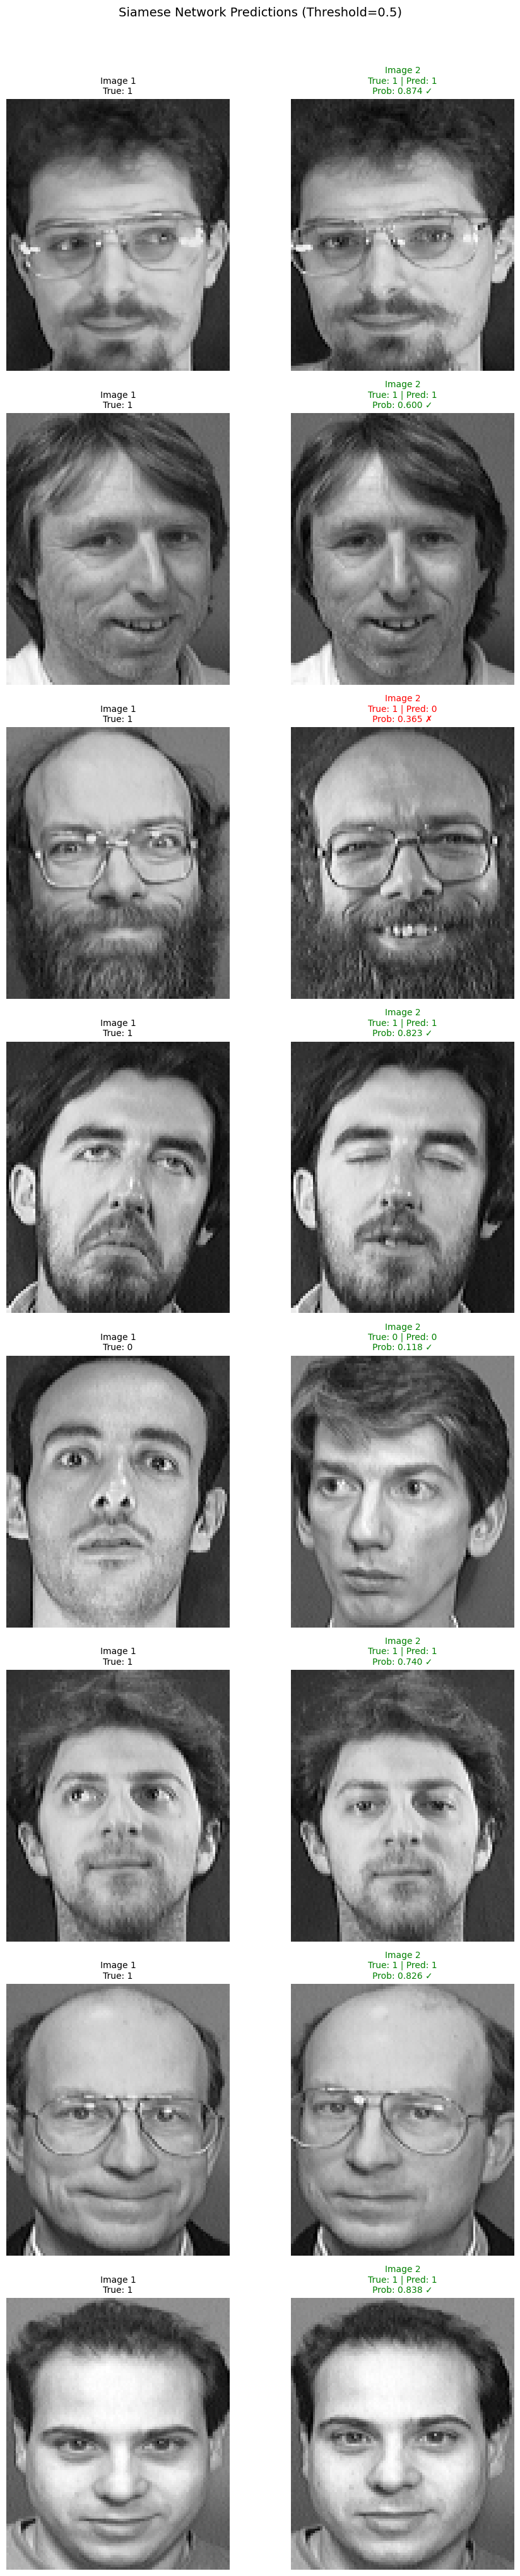

In [51]:
visualize_pairs(val_loader=val_loader, model=model, device=device)